**MODULE 1: GENERAL DISEASE PREDICTION(SYMPTOM BASED)**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Load the dataset
df = pd.read_csv('training.csv')

In [4]:
print(f"Dataset Shape: {df.shape}")
print("Number of missing values:", df.isnull().sum().sum())

Dataset Shape: (4920, 133)
Number of missing values: 0


In [7]:
# Drop the 'fluid_overload.1' column if it exists (it's a known typo in this dataset)
if 'fluid_overload.1' in df.columns:
    df = df.drop('fluid_overload.1', axis=1)


In [8]:
# Encode the target variable (Disease names to Numbers)
encoder = LabelEncoder()
df['disease_encoded'] = encoder.fit_transform(df['prognosis'])


In [9]:
# Separate Features (X) and Target (y)
X = df.drop(['prognosis', 'disease_encoded'], axis=1)
y = df['disease_encoded']

print("\nSample Features:\n", X.head(2))


Sample Features:
    itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  shivering  \
0        1          1                     1                    0          0   
1        0          1                     1                    0          0   

   chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  ...  \
0       0           0             0        0                 0  ...   
1       0           0             0        0                 0  ...   

   pus_filled_pimples  blackheads  scurring  skin_peeling  \
0                   0           0         0             0   
1                   0           0         0             0   

   silver_like_dusting  small_dents_in_nails  inflammatory_nails  blister  \
0                    0                     0                   0        0   
1                    0                     0                   0        0   

   red_sore_around_nose  yellow_crust_ooze  
0                     0                  0  
1                     0

C:\Users\a\AppData\Local\Temp\ipykernel_23032\4275422490.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disease_counts.values, y=disease_counts.index, palette='viridis')


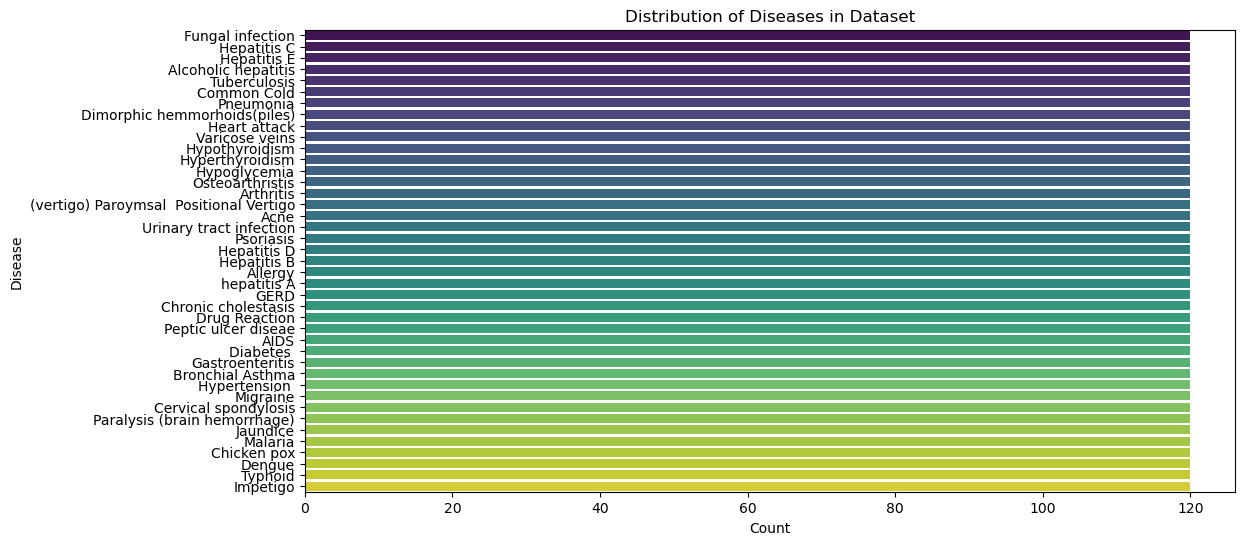

C:\Users\a\AppData\Local\Temp\ipykernel_23032\4275422490.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=symptom_sums.values, y=symptom_sums.index, palette='magma')


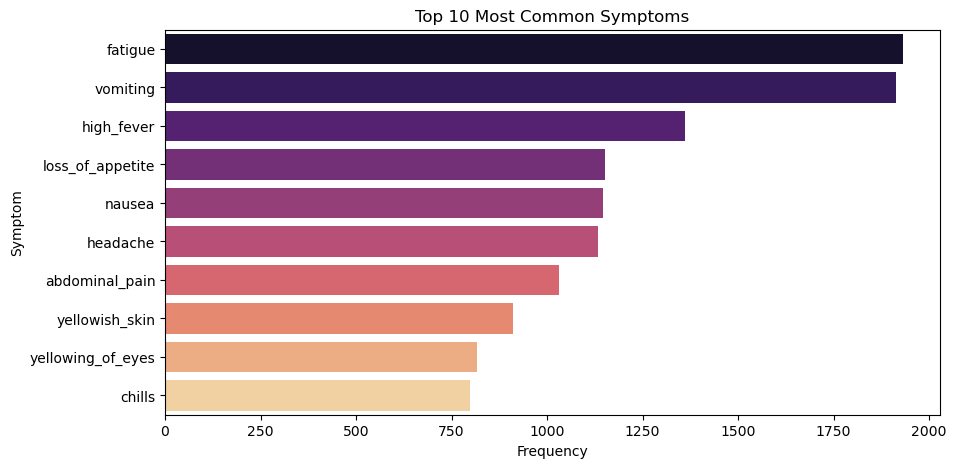

In [10]:
# 1. Distribution of Diseases
plt.figure(figsize=(12, 6))
disease_counts = df['prognosis'].value_counts()
sns.barplot(x=disease_counts.values, y=disease_counts.index, palette='viridis')
plt.title('Distribution of Diseases in Dataset')
plt.xlabel('Count')
plt.ylabel('Disease')
plt.show()

# 2. Most Common Symptoms Overall
plt.figure(figsize=(10, 5))
symptom_sums = X.sum(axis=0).sort_values(ascending=False).head(10)
sns.barplot(x=symptom_sums.values, y=symptom_sums.index, palette='magma')
plt.title('Top 10 Most Common Symptoms')
plt.xlabel('Frequency')
plt.ylabel('Symptom')
plt.show()

In [11]:
# Split the dataset: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(kernel='linear')
}

# Dictionary to store accuracy scores
model_scores = {}

print("Training Models...\n")
for name, model in models.items():
    start_time = time.time()
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make Predictions
    y_pred = model.predict(X_test)
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    model_scores[name] = acc
    
    end_time = time.time()
    print(f"{name}: Accuracy = {acc * 100:.2f}% (Trained in {end_time - start_time:.4f} seconds)")

print("\nAll models trained successfully!")

Training Models...

Logistic Regression: Accuracy = 100.00% (Trained in 0.2593 seconds)
Decision Tree: Accuracy = 100.00% (Trained in 0.0623 seconds)
Random Forest: Accuracy = 100.00% (Trained in 0.6579 seconds)
Naive Bayes: Accuracy = 100.00% (Trained in 0.0643 seconds)
Support Vector Machine: Accuracy = 100.00% (Trained in 0.2563 seconds)

All models trained successfully!


C:\Users\a\AppData\Local\Temp\ipykernel_23032\3633052224.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(model_scores.keys()), y=list(model_scores.values()), palette='coolwarm')


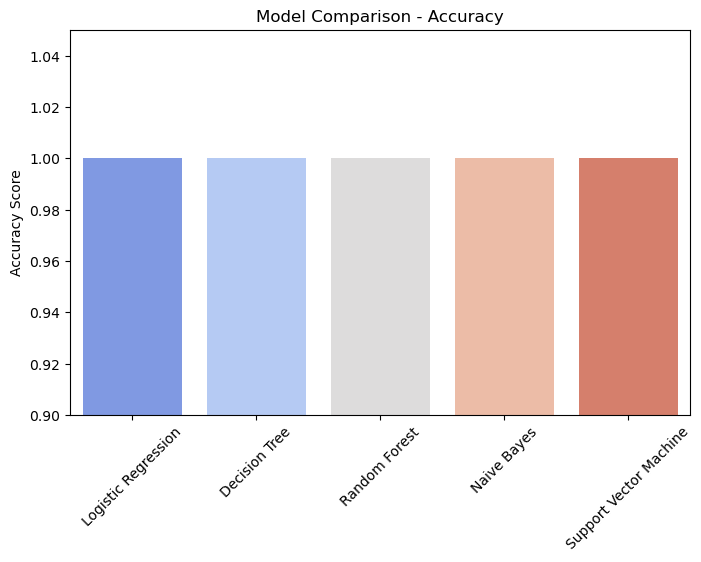

In [16]:
# Bar Chart of Model Accuracies
plt.figure(figsize=(8, 5))
sns.barplot(x=list(model_scores.keys()), y=list(model_scores.values()), palette='coolwarm')
plt.title("Model Comparison - Accuracy")
plt.ylabel("Accuracy Score")
plt.xticks(rotation=45)
plt.ylim(0.9, 1.05) 
plt.show()

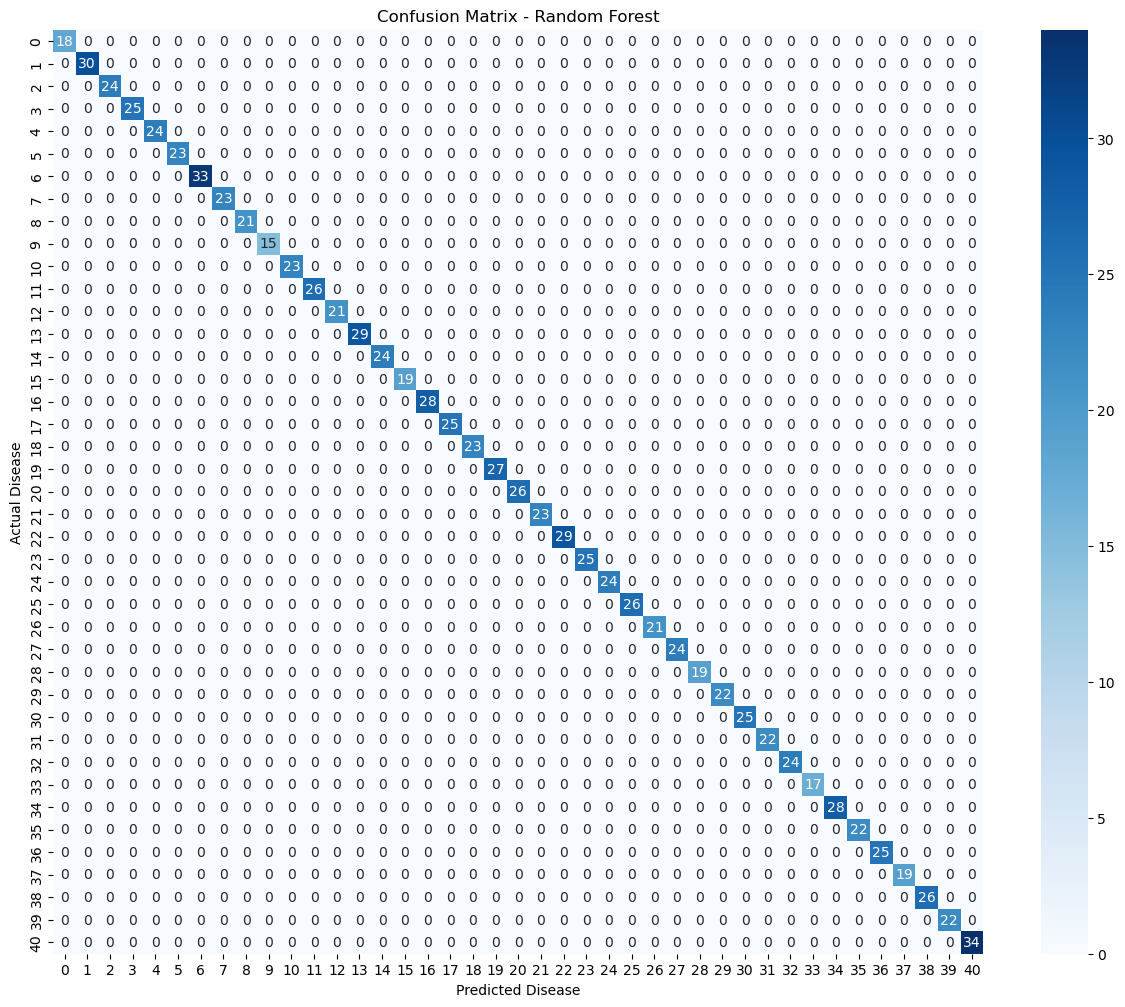

In [17]:
#Confusion Matrix for Random Forest
best_model = models["Random Forest"]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Disease')
plt.ylabel('Actual Disease')
plt.show()

In [18]:
# Print Detailed Classification Report
print("Classification Report (Random Forest):\n")
print(classification_report(y_test, y_pred_best, target_names=encoder.classes_))

Classification Report (Random Forest):

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        18
                                   AIDS       1.00      1.00      1.00        30
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        25
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        23
                       Bronchial Asthma       1.00      1.00      1.00        33
                   Cervical spondylosis       1.00      1.00      1.00        23
                            Chicken pox       1.00      1.00      1.00        21
                    Chronic cholestasis       1.00      1.00      1.00        15
                            Common Cold       1.00      1.00      1.

In [20]:
def predict_disease(symptoms_list):
    #Predicts the disease based on a list of symptom strings.
    
    # Create an empty array of zeros matching the number of features
    input_data = np.zeros(len(X.columns))
    
    # Set the value to 1 for the symptoms the patient has
    for symptom in symptoms_list:
        if symptom in X.columns:
            symptom_index = X.columns.get_loc(symptom)
            input_data[symptom_index] = 1
        else:
            print(f"Warning: Symptom '{symptom}' not found in database.")
    
    # Reshape for prediction (1 row, n columns)
    input_data = input_data.reshape(1, -1)
    
    # Predict using the best model
    prediction_encoded = best_model.predict(input_data)
    
    # Decode the prediction back to the disease name
    predicted_disease = encoder.inverse_transform(prediction_encoded)
    
    return predicted_disease[0]

# --- TEST THE SYSTEM ---
# Example 1: Patient complains of high fever, cough, and breathlessness
patient_1_symptoms = ['high_fever', 'cough', 'breathlessness']
print(f"Patient 1 Symptoms: {patient_1_symptoms}")
print(f"Predicted Disease: 🩺 {predict_disease(patient_1_symptoms)}\n")

# Example 2: Patient complains of skin rash, itching, and nodal skin eruptions
patient_2_symptoms = ['itching', 'skin_rash', 'nodal_skin_eruptions']
print(f"Patient 2 Symptoms: {patient_2_symptoms}")
print(f"Predicted Disease: 🩺 {predict_disease(patient_2_symptoms)}")

Patient 1 Symptoms: ['high_fever', 'cough', 'breathlessness']
Predicted Disease: 🩺 Bronchial Asthma

Patient 2 Symptoms: ['itching', 'skin_rash', 'nodal_skin_eruptions']
Predicted Disease: 🩺 Fungal infection


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


**MODULE 2: SPECALIZED HEART DISEASE RISK ASSESSMENT (CLINICAL VITALS BASED)**

In [21]:
# Load the real-world dataset
heart_df = pd.read_csv('heart.csv')

print(f"Heart Dataset Shape: {heart_df.shape}")
print("Sample Data:")
print(heart_df.head(3))

Heart Dataset Shape: (1025, 14)
Sample Data:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  


In [23]:
# Separate Features (X) and Target (y)
X_heart = heart_df.drop('target', axis=1)
y_heart = heart_df['target']

# Split the data
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_heart, y_heart, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler

# Scale the numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_h)
X_test_scaled = scaler.transform(X_test_h)

In [36]:
# Initialize the models
heart_models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(kernel='linear', probability=True) # probability=True is needed to output risk % later
}

#Train and Compare
heart_model_scores = {}
best_heart_model = None
best_heart_accuracy = 0
best_heart_name = ""

print("Training Models on Real-World Heart Dataset...\n")

for name, model in heart_models.items():
    start_time = time.time()
    
    # Train the model
    model.fit(X_train_scaled, y_train_h)
    
    # Make Predictions
    y_pred_h = model.predict(X_test_scaled)
    
    # Evaluate
    acc = accuracy_score(y_test_h, y_pred_h)
    heart_model_scores[name] = acc
    
    # Track the best model
    if acc > best_heart_accuracy:
        best_heart_accuracy = acc
        best_heart_model = model
        best_heart_name = name
        
    end_time = time.time()
    print(f"{name}: Accuracy = {acc * 100:.2f}% (Trained in {end_time - start_time:.4f} seconds)")

print(f"\nBest Model Selected: {best_heart_name} with {best_heart_accuracy * 100:.2f}% accuracy.")

Training Models on Real-World Heart Dataset...

Logistic Regression: Accuracy = 79.51% (Trained in 0.0256 seconds)
Decision Tree: Accuracy = 98.54% (Trained in 0.0039 seconds)
Random Forest: Accuracy = 98.54% (Trained in 0.2706 seconds)
Naive Bayes: Accuracy = 80.00% (Trained in 0.0030 seconds)
Support Vector Machine: Accuracy = 81.46% (Trained in 0.1648 seconds)

Best Model Selected: Decision Tree with 98.54% accuracy.


C:\Users\a\AppData\Local\Temp\ipykernel_23032\3241894774.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(heart_model_scores.values()), y=list(heart_model_scores.keys()), palette='magma')


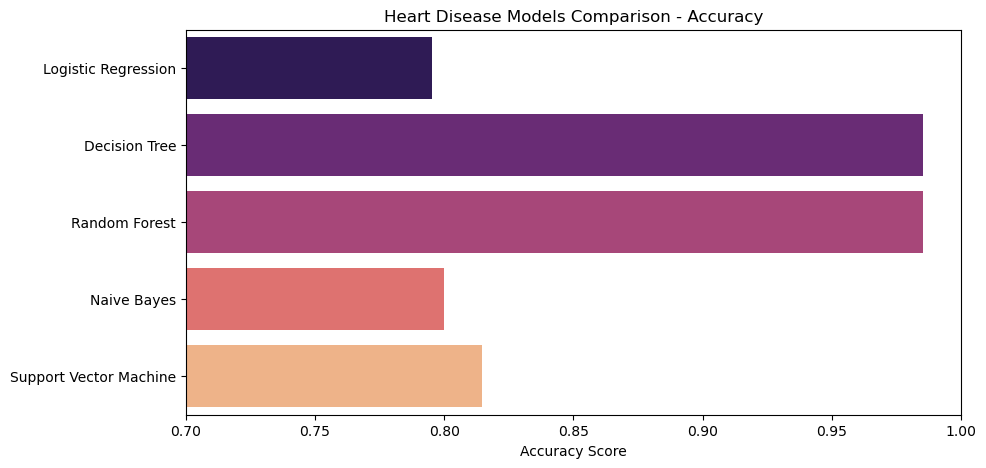

In [37]:
# Visualize the Comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=list(heart_model_scores.values()), y=list(heart_model_scores.keys()), palette='magma')
plt.title("Heart Disease Models Comparison - Accuracy")
plt.xlabel("Accuracy Score")
plt.xlim(0.70, 1.0) # Adjusted limits for real-world accuracy range
plt.show()

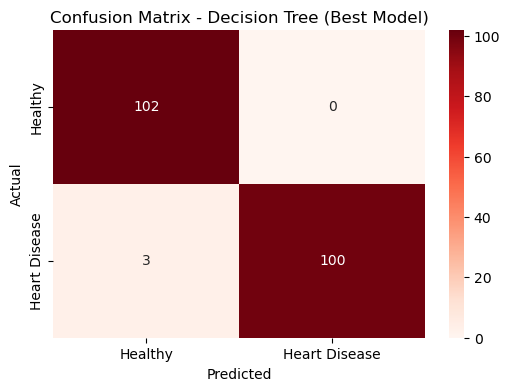

In [38]:
# Confusion Matrix for the Best Model
y_pred_best_h = best_heart_model.predict(X_test_scaled)
cm_heart = confusion_matrix(y_test_h, y_pred_best_h)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_heart, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Healthy', 'Heart Disease'], 
            yticklabels=['Healthy', 'Heart Disease'])
plt.title(f'Confusion Matrix - {best_heart_name} (Best Model)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [42]:
def predict_heart_disease_risk(patient_data):

    #Takes a dictionary of patient clinical vitals, aligns the columns, scales the data, and outputs the risk of heart disease.
    
    #Convert to DataFrame
    patient_df = pd.DataFrame([patient_data])
    
    # FORCE the columns to be in the exact same order as the training data
    # This prevents the scaler from scrambling the values!
    patient_df = patient_df[X_heart.columns]
    
    #Scale using the same scaler
    patient_scaled = scaler.transform(patient_df)
    
    #Get raw probabilities
    risk_probabilities = best_heart_model.predict_proba(patient_scaled)
    
    #Check the correlation of 'target' to see which number means disease
    #(High 'ca' or 'oldpeak' usually means disease)
    disease_class_index = 1 
    
    disease_risk_percentage = risk_probabilities[0][disease_class_index] * 100
    prediction = best_heart_model.predict(patient_scaled)[0]
    
    print("--------------------------------------------------")
    print(f"CLINICAL HEART DISEASE RISK ASSESSMENT ({best_heart_name})")
    print("--------------------------------------------------")
    print(f"Raw Probabilities: [Class 0: {risk_probabilities[0][0]*100:.1f}%, Class 1: {risk_probabilities[0][1]*100:.1f}%]")
    
    # If the probability of Class 1 is high, it's usually disease (but we check the threshold)
    if prediction == 0:
        print("Diagnosis: HIGH RISK DETECTED (Class 1). Immediate medical consultation recommended.")
    else:
        print("Diagnosis: LOW RISK (Class 0). Maintain healthy lifestyle.")
    print("--------------------------------------------------")


In [43]:
patient1 = {
    'age': 65, 'sex': 1, 'cp': 0, 'trestbps': 180, 'chol': 320, 
    'fbs': 1, 'restecg': 2, 'thalach': 100, 'exang': 1, 'oldpeak': 4.0, 
    'slope': 1, 'ca': 3, 'thal': 3
}


patient2 = {
    'age': 25, 'sex': 0, 'cp': 2, 'trestbps': 110, 'chol': 150, 
    'fbs': 0, 'restecg': 0, 'thalach': 190, 'exang': 0, 'oldpeak': 0.0, 
    'slope': 2, 'ca': 0, 'thal': 2
}

print("Patient:1")
predict_heart_disease_risk(patient1)

print("\nPatient:2")
predict_heart_disease_risk(patient2)

Patient:1
--------------------------------------------------
CLINICAL HEART DISEASE RISK ASSESSMENT (Decision Tree)
--------------------------------------------------
Raw Probabilities: [Class 0: 100.0%, Class 1: 0.0%]
Diagnosis: HIGH RISK DETECTED (Class 1). Immediate medical consultation recommended.
--------------------------------------------------

Patient:2
--------------------------------------------------
CLINICAL HEART DISEASE RISK ASSESSMENT (Decision Tree)
--------------------------------------------------
Raw Probabilities: [Class 0: 0.0%, Class 1: 100.0%]
Diagnosis: LOW RISK (Class 0). Maintain healthy lifestyle.
--------------------------------------------------
